[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tommy-Burns/easy-eo/blob/main/examples/03_real_world/01_flood_mapping_ndwi.ipynb)

# Flood mapping with NDWI

Map the extent of a real flood by comparing surface water before and after it, and measure how much land went under.

**The event.** In the summer of 2022 an extreme monsoon put roughly a third of Pakistan under water. This notebook looks at a 20 x 20 km area of Sindh province near Larkana, comparing a pre-monsoon scene in July with a post-flood scene at the end of September.

- **Data:** Sentinel-2 L2A from Microsoft Planetary Computer
- **Network: required.** This notebook queries a live catalog, so its outputs are not stored in the repository — run it yourself.
- **Requires:** `pip install "easy-eo[stac]"`

In [ ]:
# Running in Colab? Install Easy-EO. Does nothing anywhere else.
import sys

if "google.colab" in sys.modules:
    %pip install -q "easy-eo[stac]"


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

In [2]:
import numpy as np

import eeo

# Sindh province, Pakistan — Indus floodplain near Larkana
AOI = (68.10, 27.35, 68.30, 27.55)

## Finding a scene on each side of the flood

Two searches: one before the monsoon, one after the peak. Cloud cover matters enormously here - a flood is only mappable on a clear day, and the monsoon supplies very few of them.

In [3]:
before = eeo.stac_search(
    "sentinel-2-l2a", bbox=AOI, datetime="2022-06-20/2022-07-15", cloud_cover=1, limit=5
)
after = eeo.stac_search(
    "sentinel-2-l2a", bbox=AOI, datetime="2022-09-20/2022-09-30", cloud_cover=1, limit=5
)

print("before the flood:")
for item in before:
    print(f"  {item.timestamp:%Y-%m-%d}  cloud {item.cloud_cover:.2f}%")

print("\nafter the flood:")
for item in after:
    print(f"  {item.timestamp:%Y-%m-%d}  cloud {item.cloud_cover:.2f}%")

before the flood:
  2022-06-25  cloud 0.24%
  2022-06-25  cloud 0.28%
  2022-07-12  cloud 0.13%

after the flood:
  2022-09-23  cloud 0.03%
  2022-09-25  cloud 0.09%
  2022-09-28  cloud 0.02%
  2022-09-28  cloud 0.03%
  2022-09-30  cloud 0.04%


In [4]:
pre_item = before[-1]
post_item = after[-1]

print("pre :", pre_item.timestamp.date(), pre_item.id)
print("post:", post_item.timestamp.date(), post_item.id)

pre : 2022-07-12 S2A_MSIL2A_20220712T055651_R091_T42RVR_20220713T162353
post: 2022-09-30 S2A_MSIL2A_20220930T055641_R091_T42RVR_20220930T194858


## Loading only what we need

NDWI needs two bands: green (B03) and near-infrared (B08). Both scenes are cropped to the search AOI automatically, so we read a 20 km window rather than a 110 km tile.

In [5]:
pre = pre_item.load(["B03", "B08"])
post = post_item.load(["B03", "B08"])

print("pre :", pre.get_shape(), pre.get_crs())
print("post:", post.get_shape(), post.get_crs())
pre.describe()

pre : (2229, 1991) EPSG:32642
post: (2229, 1991) EPSG:32642
EEORasterDataset
  source      : <in-memory>
  driver      : GTiff
  bands       : 2
  band names  : 1: B03, 2: B08
  size        : 2229 × 1991  (height × width)
  dtype       : uint16
  crs         : EPSG:32642 — WGS 84 / UTM zone 42N
  pixel size  : 10 × 10  (CRS units)
  extent      : 410980, 3025390, 430890, 3047680  (minx, miny, maxx, maxy)
  nodata      : 0.0
  timestamp   : 2022-07-12T05:56:51.024000+00:00
  attrs       : stac_item=S2A_MSIL2A_20220712T055651_R091_T42RVR_20220713T162353, stac_collection=sentinel-2-l2a, stac_assets=['B03', 'B08']


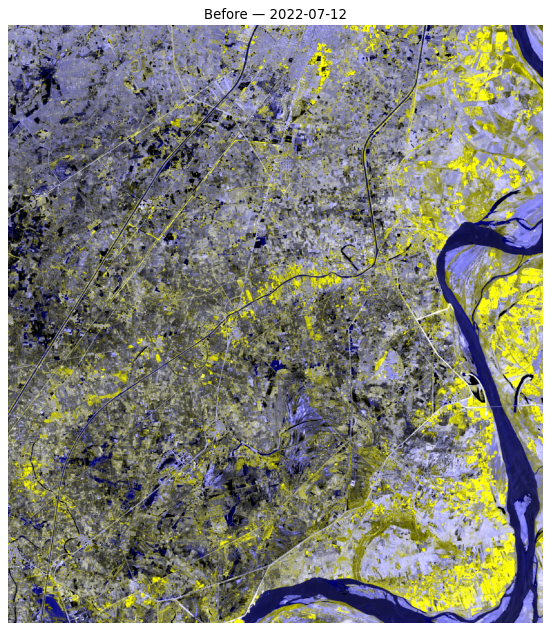

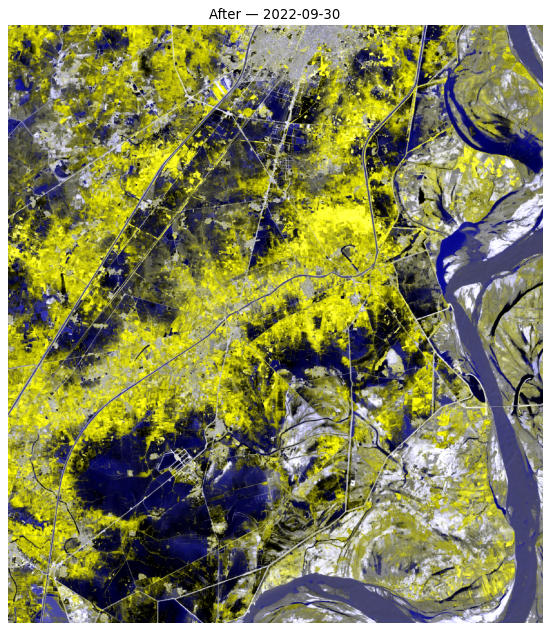

In [6]:
pre.plot_composite(["B08", "B08", "B03"], pmin=2, pmax=98,
                   title=f"Before — {pre_item.timestamp:%Y-%m-%d}")
post.plot_composite(["B08", "B08", "B03"], pmin=2, pmax=98,
                    title=f"After — {post_item.timestamp:%Y-%m-%d}")

Water absorbs near-infrared almost completely, so flooded ground is already obvious as dark areas in the post-flood image. NDWI turns that contrast into a number.

## NDWI

McFeeters' water index: `(Green - NIR) / (Green + NIR)`. Water is positive because it reflects more green than near-infrared; vegetation and soil are negative.

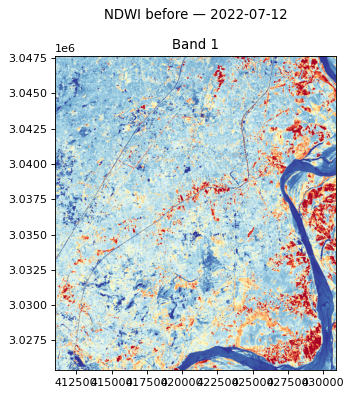

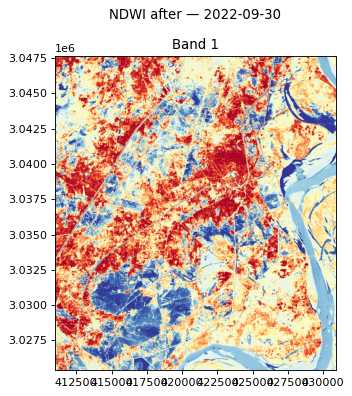

In [7]:
ndwi_pre = pre.ndwi(nir="B08", green="B03")
ndwi_post = post.ndwi(nir="B08", green="B03")

ndwi_pre.plot_raster(cmap="RdYlBu", title=f"NDWI before — {pre_item.timestamp:%Y-%m-%d}")
ndwi_post.plot_raster(cmap="RdYlBu", title=f"NDWI after — {post_item.timestamp:%Y-%m-%d}")

## Choosing a threshold

Never pick a threshold without looking at the histogram. The post-flood distribution should be visibly **bimodal** - one peak for land, a second for water - and the right threshold sits in the valley between them.

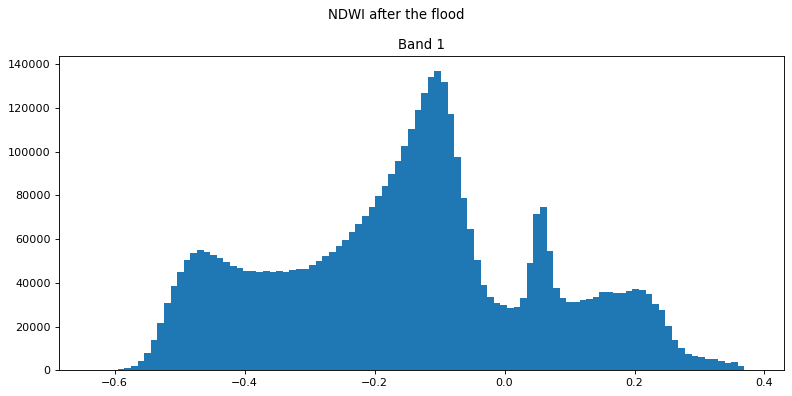

In [8]:
ndwi_post.plot_histogram(bins=100, title="NDWI after the flood")

In [9]:
water_pre = ndwi_pre.get_band(1)
water_post = ndwi_post.get_band(1)

print(f"{'threshold':>10s} {'before':>10s} {'after':>10s}")
for threshold in (-0.1, -0.05, 0.0, 0.05, 0.1, 0.2):
    print(f"{threshold:10.2f} {np.nanmean(water_pre > threshold) * 100:9.2f}% "
          f"{np.nanmean(water_post > threshold) * 100:9.2f}%")

 threshold     before      after
     -0.10     33.14%     38.54%
     -0.05     11.13%     27.21%
      0.00      6.64%     22.91%
      0.05      1.78%     18.67%
      0.10      0.95%     13.07%
      0.20      0.26%      5.47%


`0` is the conventional cut for NDWI and works well here. Be aware that it is a convention, not a physical constant — turbid floodwater carrying sediment sits lower than clear open water, so a threshold tuned on a lake will under-detect a flood.

In [10]:
THRESHOLD = 0.0

mask_pre = water_pre > THRESHOLD
mask_post = water_post > THRESHOLD

pixel_area_km2 = abs(pre.get_transform().a * pre.get_transform().e) / 1e6

print(f"permanent water : {mask_pre.sum() * pixel_area_km2:8.2f} km^2  ({mask_pre.mean() * 100:5.2f}%)")
print(f"water after     : {mask_post.sum() * pixel_area_km2:8.2f} km^2  ({mask_post.mean() * 100:5.2f}%)")

permanent water :    29.45 km^2  ( 6.64%)
water after     :   101.67 km^2  (22.91%)


## The flood extent

Newly flooded land is what is water **after** but was not water **before**. Subtracting the permanent water bodies is what turns a water map into a flood map.

In [11]:
newly_flooded = mask_post & ~mask_pre
drained = mask_pre & ~mask_post

print(f"newly flooded : {newly_flooded.sum() * pixel_area_km2:8.2f} km^2")
print(f"receded       : {drained.sum() * pixel_area_km2:8.2f} km^2")
print(f"net change    : {(mask_post.sum() - mask_pre.sum()) * pixel_area_km2:8.2f} km^2")
print(f"\nshare of the study area newly under water: {newly_flooded.mean() * 100:.1f}%")

newly flooded :    79.08 km^2
receded       :     6.86 km^2
net change    :    72.22 km^2

share of the study area newly under water: 17.8%


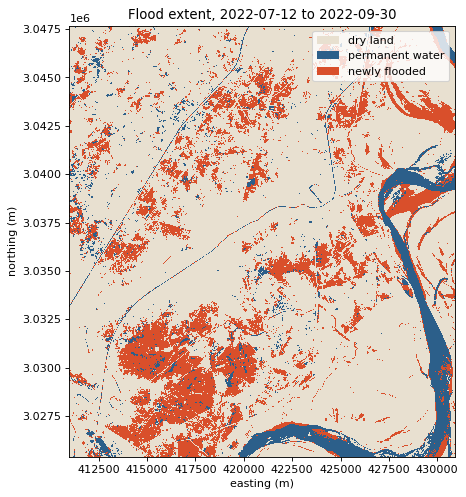

In [12]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# 0 = dry, 1 = permanent water, 2 = newly flooded
classes = np.zeros(mask_post.shape, dtype="uint8")
classes[mask_pre] = 1
classes[newly_flooded] = 2

bounds = pre.get_bounds()
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
cmap = ListedColormap(["#e8e0d0", "#2c5f8a", "#d94f2b"])

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(classes, cmap=cmap, vmin=0, vmax=2, extent=extent, interpolation="nearest")
ax.set_title(f"Flood extent, {pre_item.timestamp:%Y-%m-%d} to {post_item.timestamp:%Y-%m-%d}")
ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
ax.legend(
    handles=[
        Patch(facecolor="#e8e0d0", label="dry land"),
        Patch(facecolor="#2c5f8a", label="permanent water"),
        Patch(facecolor="#d94f2b", label="newly flooded"),
    ],
    loc="upper right",
)
plt.show()

## What was flooded?

A flood map is more useful when it says what went under. NDVI before the flood separates cropland from bare ground, so we can cross-tabulate the two.

In [13]:
pre_full = pre_item.load(["B03", "B04", "B08"])
ndvi_pre = pre_full.ndvi(red="B04", nir="B08").get_band(1)

vegetated = ndvi_pre > 0.3
flooded_veg = newly_flooded & vegetated
flooded_bare = newly_flooded & ~vegetated

print(f"newly flooded, vegetated before : {flooded_veg.sum() * pixel_area_km2:7.2f} km^2")
print(f"newly flooded, bare before      : {flooded_bare.sum() * pixel_area_km2:7.2f} km^2")
print(f"\nshare of pre-flood cropland inundated: "
      f"{flooded_veg.sum() / max(vegetated.sum(), 1) * 100:.1f}%")

newly flooded, vegetated before :    1.56 km^2
newly flooded, bare before      :   77.52 km^2

share of pre-flood cropland inundated: 4.1%


## Saving the result

Write the flood mask as a GeoTIFF so it can go into QGIS or a report. Wrapping the mask with `load_array` gives it the scene's georeferencing.

In [14]:
import tempfile
from pathlib import Path

from eeo import load_array

out_dir = Path(tempfile.mkdtemp())

flood_ds = load_array(
    newly_flooded.astype("uint8"),
    crs=pre.get_crs(),
    transform=pre.get_transform(),
    nodata=0,
    band_names=["newly_flooded"],
)
flood_ds.save_raster(str(out_dir / "flood_extent.tif"))
print("written:", out_dir / "flood_extent.tif")
flood_ds.describe()

written: /tmp/tmp_y0pwatc/flood_extent.tif
EEORasterDataset
  source      : <in-memory>
  driver      : GTiff
  bands       : 1
  band names  : 1: newly_flooded
  size        : 2229 × 1991  (height × width)
  dtype       : uint8
  crs         : EPSG:32642 — WGS 84 / UTM zone 42N
  pixel size  : 10 × 10  (CRS units)
  extent      : 410980, 3025390, 430890, 3047680  (minx, miny, maxx, maxy)
  nodata      : 0
  timestamp   : none
  attrs       : none


## Caveats worth stating

This is a demonstration, not an operational product. Before trusting numbers like these:

- **Cloud and cloud shadow** are not masked here. Shadow looks dark in the near-infrared and is the classic false positive for water. Use the scene classification layer (`SCL`) to mask both.
- **One date each side** captures the flood on the day the satellite passed, not the peak. The real maximum extent needs the full time series.
- **A fixed threshold** is a blunt instrument; sediment-laden floodwater sits lower in NDWI than clear water.
- **Radar sees through cloud.** For operational flood mapping, Sentinel-1 SAR is the standard instrument precisely because monsoon floods happen under cloud.

In [15]:
for ds in (pre, post, ndwi_pre, ndwi_post, pre_full, flood_ds):
    ds.close()
print("closed")

closed


## Next

- **[02_vegetation_health_and_drought](02_vegetation_health_and_drought.ipynb)** - the other side of the water story
- **[03_urban_footprint_land_cover](03_urban_footprint_land_cover.ipynb)** - multi-index classification